In [43]:
! python PytorchReachability/scripts/generate_data_traj_cont_gap.py

In [19]:
! python PytorchReachability/scripts/generate_data_traj_cont_gap.py

/home/clown2/Desktop/Work/Research/wm_cbf


(-0.5, 127.5, 127.5, -0.5)

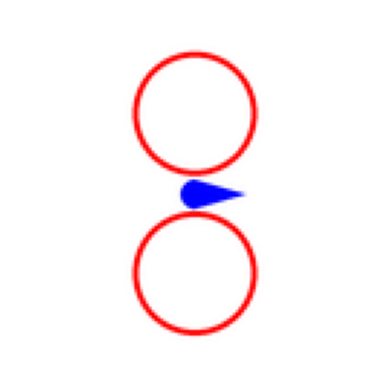

In [41]:
import dubin_multiobs_render as dmr
from latent_dubins_ca_wm_pil import *
import numpy as np
import matplotlib.pyplot as plt

config_path = 'PytorchReachability/configs_gap.yaml'
args = get_args(cfg_path=config_path)

# Render the trajectory with the environment
img = dmr.state_to_image_pil_hq(np.array([0,0,0]), args)   

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide the axes



In [20]:
# open pickle file named 'wm_demos128_gap.pkl' 

import pickle
with open('wm_demos128_gap.pkl', 'rb') as f:
    data = pickle.load(f)

/home/clown2/anaconda3/envs/wm_cbf/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


True
0


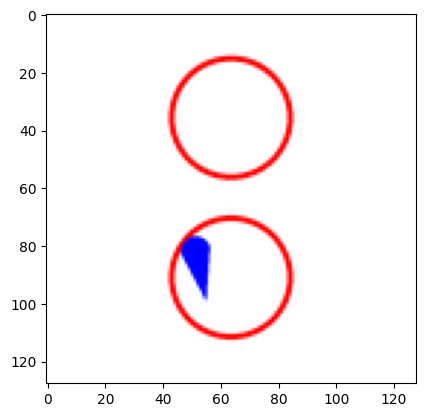

In [29]:
ntj = 1
ts = 27
img = data[ntj]['obs']['image'][ts]

import matplotlib.pyplot as plt
plt.imshow(img)

print(data[ntj]['fails'][ts])
print(data[ntj]['reward'][ts])

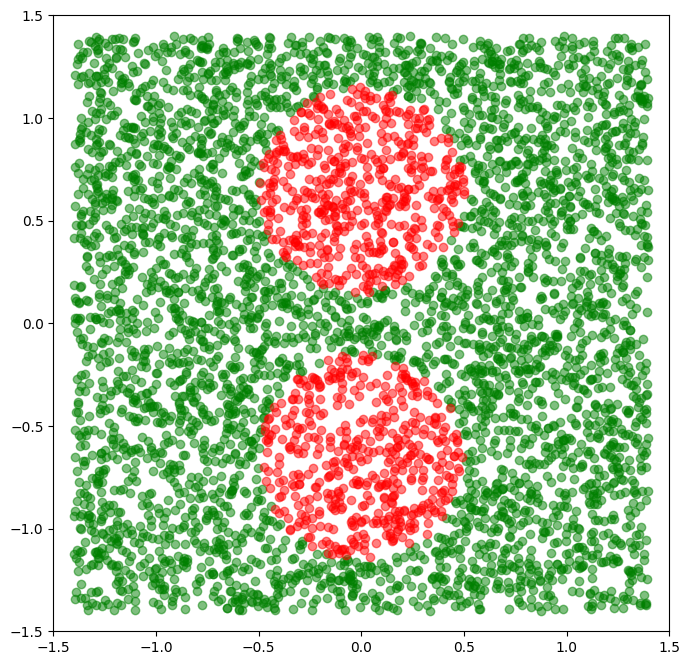

In [ ]:
from latent_dubins_ca_wm_pil import *
import matplotlib.pyplot as plt
import torch
from PytorchReachability.scripts.generate_data_traj_cont_gap import failure_check_batch

config_path = 'PytorchReachability/configs_gap.yaml'
config = get_args(cfg_path=config_path)

xs = torch.tensor([0,0])
ys = torch.tensor([0.65, -0.65])
rs = torch.tensor([0.5, 0.5])

safe_states = []
unsafe_states = []

for i in range(5000):
    states = torch.rand(3)
    states[0] *= (config.x_max-config.buffer) - (config.x_min + config.buffer)
    states[1] *= (config.y_max-config.buffer) - (config.y_min + config.buffer)
    states[0] += config.x_min + config.buffer
    states[1] += config.y_min + config.buffer

    # just add the point to an array and plot later
    if torch.any(failure_check_batch(states, xs, ys, rs)):
        unsafe_states.append(states)
    else:
        safe_states.append(states)

# Plot the safe and unsafe states
safe_states = torch.stack(safe_states)
unsafe_states = torch.stack(unsafe_states)
plt.figure(figsize=(8, 8))
plt.scatter(safe_states[:, 0], safe_states[:, 1], color='green', label='Safe States', alpha=0.5)
plt.scatter(unsafe_states[:, 0],
                unsafe_states[:, 1], color='red', label='Unsafe States', alpha=0.5)

# equal axes
plt.xlim(config.x_min, config.x_max)
plt.ylim(config.y_min, config.y_max)
plt.gca().set_aspect('equal', adjustable='box')